# Single-Marker Ablation Analysis

This notebook trains either one 80/20 train/validation split for testing or five organoid-level folds for the final analysis. It then estimates two distinct single-cell ablation quantities:

1. **Center-resolved effects** from normalized marker-pair coverage sampling.
2. **Population effects** from average-organoid sampling, with marker-specific top-ups used only for conditional effects.

All analyses report changes in predicted curvature, predicted variance, and squared prediction error. A MAD outlier mask derived from the curvature change is applied unchanged to all three metrics. Population effects include distance zero; center-resolved effects begin at distance one.


**Setup**

In [86]:
import copy
import json
import pickle
import random
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_ROOT = PROJECT_ROOT / "training_data"
sys.path.append(str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATA_ROOT    =", DATA_ROOT)
print("torch        =", torch.__version__)
print("cuda         =", torch.cuda.is_available())


PROJECT_ROOT = /home/fmoller/Projects/LearningOrganoids/GraphNN
DATA_ROOT    = /home/fmoller/Projects/LearningOrganoids/GraphNN/training_data
torch        = 2.8.0+cu128
cuda         = True


**Settings**

In [87]:
# Data and filtering
EXPERIMENT_GROUP = "ablation_analysis"
DATASET_NAME = "fixed_new"
TARGET_INDICES = [0]
TARGET_INDEX_FOR_ANALYSIS = 0

USE_GLOBAL_FEATURES = True
FILTER_BLACKLISTED_ORGANOIDS = True
SUBTRACT_CONSTANT_GLOBAL_BASELINE = False

TIMEPOINT_FILTER_MODE = "rest"  # "rest", "day3p5", or "all"
DAY3P5_TIMEPOINT = "day3p5"
FILL_MISSING_COMPLEXITY = True
MISSING_COMPLEXITY_GROUP = {
    "dataset": "20251201",
    "timepoint": "day4p5",
    "fill_value": 2.1,
}
SPHERICITY_MAX = 0.92 # 0.96
SPHERICAL_MARKER_DIVERSITY_MIN = 0.5
COMPLEXITY_MIN = 2.0
INTERPOLATE_TARGET_OUTLIERS = True
OUTLIER_CLIP_QUANTILES = (0.005, 0.995)

# Split mode
ANALYSIS_MODE = "folded"  # "single_split" for testing, "folded" for final results
VAL_FRAC = 0.2
N_FOLDS = 5
SPLIT_SEED = 42

# Model and training
NUM_LAYERS = 2
HIDDEN_DIM = 4 * 64
DROPOUT = 0.1
NORM = "batch"
RESIDUAL = True
LR = 3e-4
BATCH_SIZE = 128
MAX_EPOCHS = 500
PATIENCE = 30
NUM_WORKERS = 4
EDGE_LOSS_WEIGHT = 0.20
EDGE_LOSS_PARAMS = {
    "weighted": False,
    "alpha": 2.0,
    "normalize_by": "graph_std",
    "clip_weight": 4.0,
}

# Sampling and single-marker ablation
PERTURBATION_MODE = "single"
SUBGRAPH_SEED = 0
PERTURB_BATCH_SIZE = 128

CENTER_SAMPLE_SIZE = 2000 # 500 #2000
CENTER_MIN_MARKER_COUNT = 50 # 25 #50
CENTER_MIN_PAIR_COUNT = 25 #15 #25
HEATMAP_DISPLAY_MIN_CASES = 20 # 6 #20

POPULATION_SAMPLE_SIZE = 2000 # 500 #2000
POPULATION_WEIGHTING = "organoid"
MIN_MARKER_COUNT_PER_HOP = 75 # 25 # 75

# Curvature-derived robust filtering. The resulting mask is reused for all metrics.
OUTLIER_FILTER_METHOD = "mad"  # None or "mad"
OUTLIER_MAD_Z = 3.5
OUTLIER_MIN_GROUP_SIZE = 20 # 6 #20
OUTLIER_TAIL = "both"  # "both", "lower", or "upper"

# Output
RUN_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_NAME = f"{ANALYSIS_MODE}_depth{NUM_LAYERS}_{RUN_TIMESTAMP}"
SAVE_DIR = PROJECT_ROOT / "results_experiments" / EXPERIMENT_GROUP / RUN_NAME
FIGURES_DIR = SAVE_DIR / "figures"
TABLES_DIR = SAVE_DIR / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

random.seed(SPLIT_SEED)
np.random.seed(SPLIT_SEED)
torch.manual_seed(SPLIT_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SPLIT_SEED)


**Utility Helpers**

In [88]:
def save_figure(fig, name, *, dpi=300):
    for suffix in ("pdf", "png"):
        fig.savefig(FIGURES_DIR / f"{name}.{suffix}", dpi=dpi, bbox_inches="tight")


def select_target_column(values, target_index=0):
    arr = np.asarray(values)
    if arr.ndim == 1:
        return arr
    return arr[:, int(target_index)]


def jsonable(obj):
    if isinstance(obj, dict):
        return {str(k): jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple, set)):
        return [jsonable(v) for v in obj]
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, np.generic):
        return obj.item()
    if isinstance(obj, torch.Tensor):
        return obj.detach().cpu().tolist()
    if isinstance(obj, (torch.dtype, np.dtype)):
        return str(obj)
    return obj


def weighted_mean(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    valid = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    if not np.any(valid):
        return np.nan
    return float(np.average(values[valid], weights=weights[valid]))


def weighted_std(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    valid = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    if not np.any(valid):
        return np.nan
    values = values[valid]
    weights = weights[valid]
    mean = np.average(values, weights=weights)
    return float(np.sqrt(np.average((values - mean) ** 2, weights=weights)))


def effective_sample_size(weights):
    weights = np.asarray(weights, dtype=float)
    weights = weights[np.isfinite(weights) & (weights > 0)]
    if len(weights) == 0:
        return 0.0
    return float(weights.sum() ** 2 / np.square(weights).sum())


def weighted_quantile(values, quantile, weights=None):
    values = np.asarray(values, dtype=float)
    weights = np.ones(len(values), dtype=float) if weights is None else np.asarray(weights, dtype=float)
    valid = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    values = values[valid]
    weights = weights[valid]
    if len(values) == 0:
        return np.nan
    order = np.argsort(values)
    values = values[order]
    weights = weights[order]
    cumulative = np.cumsum(weights) - 0.5 * weights
    cumulative /= weights.sum()
    return float(np.interp(quantile, cumulative, values))


def robust_outlier_mask(values, weights=None):
    values = np.asarray(values, dtype=float)
    mask = np.zeros(len(values), dtype=bool)
    if OUTLIER_FILTER_METHOD is None:
        return mask
    if OUTLIER_FILTER_METHOD != "mad":
        raise ValueError('OUTLIER_FILTER_METHOD must be None or "mad".')
    if OUTLIER_TAIL not in {"both", "lower", "upper"}:
        raise ValueError('OUTLIER_TAIL must be "both", "lower", or "upper".')

    valid = np.isfinite(values)
    if weights is not None:
        weights = np.asarray(weights, dtype=float)
        valid &= np.isfinite(weights) & (weights > 0)
    if valid.sum() < OUTLIER_MIN_GROUP_SIZE:
        return mask

    valid_values = values[valid]
    valid_weights = None if weights is None else weights[valid]
    median = weighted_quantile(valid_values, 0.5, valid_weights)
    mad = weighted_quantile(np.abs(valid_values - median), 0.5, valid_weights)
    robust_scale = 1.4826 * mad
    if not np.isfinite(robust_scale) or robust_scale <= 0:
        return mask

    lower = median - OUTLIER_MAD_Z * robust_scale
    upper = median + OUTLIER_MAD_Z * robust_scale
    valid_mask = np.zeros(len(valid_values), dtype=bool)
    if OUTLIER_TAIL in {"both", "lower"}:
        valid_mask |= valid_values < lower
    if OUTLIER_TAIL in {"both", "upper"}:
        valid_mask |= valid_values > upper
    mask[np.flatnonzero(valid)] = valid_mask
    return mask


def flag_groupwise_outliers(df, group_columns, value_column, weight_column=None):
    flagged = df.copy().reset_index(drop=True)
    flags = np.zeros(len(flagged), dtype=bool)
    grouped_positions = flagged.groupby(group_columns, dropna=False, sort=False).indices
    for positions in grouped_positions.values():
        positions = np.asarray(positions, dtype=int)
        group = flagged.iloc[positions]
        weights = None if weight_column is None else group[weight_column].to_numpy(float)
        flags[positions] = robust_outlier_mask(group[value_column].to_numpy(float), weights)
    flagged["is_outlier"] = flags
    return flagged


## 1. Load And Filter Data

In [89]:
from src.data.filters import (
    filter_graphs_by_blacklist,
    filter_graphs_by_marker_diversity,
    filter_graphs_by_metadata,
    filter_graphs_by_numeric_metadata,
    filter_graphs_by_sphericity,
    load_graph_blacklist_from_dir,
)
from src.data.io import load_graph_dataset_from_dir, select_graph_targets
from src.data.metadata import (
    add_log_metadata_features,
    attach_metadata_to_graphs,
    fill_missing_metadata_for_group,
    infer_global_dim,
    load_aux_metadata_for_dir,
    load_marker_names_from_dir,
    promote_metadata_to_graph_tensors,
    snapshot_graph_metadata,
    strip_graph_metadata,
)
from src.data.preprocessing import interpolate_target_outliers_from_neighbors

data_dir = DATA_ROOT / DATASET_NAME
graphs = load_graph_dataset_from_dir(str(data_dir))
meta = load_aux_metadata_for_dir(str(data_dir))
attach_metadata_to_graphs(graphs, meta, exclude_keys=None)
graphs = select_graph_targets(graphs, target_indices=TARGET_INDICES, inplace=False)
marker_names = load_marker_names_from_dir(str(data_dir))
if marker_names is None:
    marker_names = [f"marker_{i}" for i in range(int(graphs[0].x.size(1)))]
print(f"Loaded {len(graphs)} organoids and {len(marker_names)} markers.")


Loaded 1423 graphs; skipped 0.
Loaded 1423 organoids and 7 markers.


In [90]:
if TIMEPOINT_FILTER_MODE == "rest":
    graphs = filter_graphs_by_metadata(
        graphs, key="timepoint", drop_values={DAY3P5_TIMEPOINT},
        missing="keep", inplace=False, print_summary=True,
    )
elif TIMEPOINT_FILTER_MODE == "day3p5":
    graphs = filter_graphs_by_metadata(
        graphs, key="timepoint", keep_values={DAY3P5_TIMEPOINT},
        missing="drop", inplace=False, print_summary=True,
    )
elif TIMEPOINT_FILTER_MODE not in (None, "all"):
    raise ValueError('TIMEPOINT_FILTER_MODE must be "rest", "day3p5", or "all".')

if FILTER_BLACKLISTED_ORGANOIDS:
    blacklist = load_graph_blacklist_from_dir(data_dir)
    graphs = filter_graphs_by_blacklist(graphs, blacklist, print_summary=True)
else:
    blacklist = set()

if FILL_MISSING_COMPLEXITY:
    graphs = fill_missing_metadata_for_group(
        graphs,
        field="complexity",
        fill_value=MISSING_COMPLEXITY_GROUP["fill_value"],
        dataset=MISSING_COMPLEXITY_GROUP["dataset"],
        timepoint=MISSING_COMPLEXITY_GROUP["timepoint"],
    )

graphs, spherical = filter_graphs_by_sphericity(
    graphs, max_sphericity=SPHERICITY_MAX, print_summary=True, return_rejected=True,
)
spherical = filter_graphs_by_marker_diversity(
    spherical, min_score=SPHERICAL_MARKER_DIVERSITY_MIN, print_summary=True,
)
graphs = filter_graphs_by_numeric_metadata(
    graphs, key="complexity", min_value=COMPLEXITY_MIN,
    allow_missing=False, inplace=False, print_summary=True,
)
if INTERPOLATE_TARGET_OUTLIERS:
    graphs, target_outlier_info = interpolate_target_outliers_from_neighbors(
        graphs, clip_quantiles=OUTLIER_CLIP_QUANTILES,
    )
else:
    target_outlier_info = None
print(f"After filtering: {len(graphs)} organoids.")


filter_graphs_by_metadata(key='timepoint'): kept 1134 / 1423 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day3p5                0    289    0.000
20250929         day4                342    342    1.000
20250929         day4p5              104    104    1.000
20250929         day4p5-more         411    411    1.000
20251201         day4p5              277    277    1.000
filter_graphs_by_blacklist(n_keys=6): kept 1128 / 1134 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day4                341    342    0.997
20250929         day4p5              104    104    1.000
20250929         day4p5-more         409    411    0.995
20251201         day4p5              274    277    0.989
filter_graphs_by_sphericity(max_sphericity=0.92): kept 813 / 1128 graphs

dataset          timepoint          kept  total  

## 2. Define The Analysis Splits

In [91]:
from src.data.splits import graph_metadata_key, train_val_split_graphs


def make_organoid_kfolds(graphs_in, *, n_folds=5, seed=0):
    if len(graphs_in) < n_folds:
        raise ValueError(f"Need at least {n_folds} graphs, got {len(graphs_in)}.")
    keys = [graph_metadata_key(g) for g in graphs_in]
    if len(set(keys)) != len(keys):
        raise ValueError("Expected unique organoid metadata keys.")

    rng = np.random.default_rng(seed)
    indices = np.arange(len(graphs_in), dtype=int)
    rng.shuffle(indices)
    val_folds = np.array_split(indices, n_folds)
    splits = []
    for fold_id, val_indices in enumerate(val_folds):
        val_indices = np.asarray(val_indices, dtype=int)
        val_set = set(val_indices.tolist())
        train_indices = np.asarray(
            [i for i in range(len(graphs_in)) if i not in val_set],
            dtype=int,
        )
        splits.append({
            "fold": fold_id,
            "train_indices": train_indices,
            "val_indices": val_indices,
            "train_keys": [keys[int(i)] for i in train_indices],
            "val_keys": [keys[int(i)] for i in val_indices],
        })
    return splits


def make_analysis_splits(graphs_in):
    if ANALYSIS_MODE == "folded":
        return make_organoid_kfolds(graphs_in, n_folds=N_FOLDS, seed=SPLIT_SEED)
    if ANALYSIS_MODE != "single_split":
        raise ValueError('ANALYSIS_MODE must be "single_split" or "folded".')

    _, _, split_info = train_val_split_graphs(
        graphs_in,
        val_frac=VAL_FRAC,
        seed=SPLIT_SEED,
        key_fn=graph_metadata_key,
        inplace=False,
    )
    return [{
        "fold": 0,
        "train_indices": np.asarray(split_info["train_indices"], dtype=int),
        "val_indices": np.asarray(split_info["val_indices"], dtype=int),
        "train_keys": split_info["train_keys"],
        "val_keys": split_info["val_keys"],
    }]


splits = make_analysis_splits(graphs)
total_validation_organoids = sum(len(split["val_indices"]) for split in splits)
split_summary_df = pd.DataFrame([{
    "fold": split["fold"],
    "n_train_graphs": len(split["train_indices"]),
    "n_val_graphs": len(split["val_indices"]),
} for split in splits])
display(split_summary_df)


,fold,n_train_graphs,n_val_graphs
0,0,564,142
1,1,565,141
2,2,565,141
3,3,565,141
4,4,565,141


## 3. Fold Preparation And Model Training

In [92]:
from src.data.target_transforms import (
    AsinhStandardizeTransform,
    ChainedTargetTransform,
    GlobalBaselineResidualTransform,
    standardize_graph_global_features,
)
from src.models.gnn import GINCurvature
from src.training.loop import TrainConfig, train
from src.training.losses import WeightedLossTerm, edge_loss_term

FIELD_SPECS = [{
    "meta_keys": ["log_surface_area", "log_volume", "log_volume_over_area", "log_num_cells"],
    "attr_name": "global_feat",
    "kind": "graph_vector",
    "dtype": torch.float32,
}]


def prepare_fold_graphs(train_graphs, val_graphs):
    g_train = copy.deepcopy(train_graphs)
    g_val = copy.deepcopy(val_graphs)

    if USE_GLOBAL_FEATURES:
        g_train = promote_metadata_to_graph_tensors(
            add_log_metadata_features(g_train, inplace=False), FIELD_SPECS, inplace=False,
        )
        g_val = promote_metadata_to_graph_tensors(
            add_log_metadata_features(g_val, inplace=False), FIELD_SPECS, inplace=False,
        )

    train_meta_lookup = snapshot_graph_metadata(g_train)
    val_meta_lookup = snapshot_graph_metadata(g_val)
    g_train = strip_graph_metadata(g_train, inplace=False)
    g_val = strip_graph_metadata(g_val, inplace=False)

    if USE_GLOBAL_FEATURES:
        standardize_graph_global_features(
            g_train, g_val, attr_name="global_feat", robust=False,
        )

    if SUBTRACT_CONSTANT_GLOBAL_BASELINE:
        target_transform = ChainedTargetTransform([
            GlobalBaselineResidualTransform(num_workers=NUM_WORKERS),
            AsinhStandardizeTransform(robust=True),
        ])
    else:
        target_transform = AsinhStandardizeTransform(robust=True)
    target_transform.fit(g_train)
    target_transform.transform_graphs(g_train, in_place=True)
    target_transform.transform_graphs(g_val, in_place=True)

    return {
        "g_train": g_train,
        "g_val": g_val,
        "train_meta_lookup": train_meta_lookup,
        "val_meta_lookup": val_meta_lookup,
        "target_transform": target_transform,
    }


def make_model(g_train):
    return GINCurvature(
        n_markers=int(g_train[0].x.size(1)),
        global_dim=infer_global_dim(g_train),
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
        residual=RESIDUAL,
        norm=NORM,
    )


def make_train_config():
    return TrainConfig(
        lr=LR,
        batch_size=BATCH_SIZE,
        max_epochs=MAX_EPOCHS,
        patience=PATIENCE,
        num_workers=NUM_WORKERS,
        aux_losses=[WeightedLossTerm(
            name="edge",
            fn=edge_loss_term,
            weight=EDGE_LOSS_WEIGHT,
            params=EDGE_LOSS_PARAMS,
        )],
    )


## 4. Sampling And Perturbation Helpers

In [93]:
from src.analysis.perturbation import compute_perturbation_influence_maps
from src.data.subgraph_sampling import (
    print_sampling_summary,
    sample_subgraphs_coverage,
    sample_subgraphs_population,
)
from src.data.subgraphs import build_ego_subgraphs_for_dataset
from src.graph.neighborhood import compute_hop_rings
from src.inference.predict import predict_targets


def population_marker_prevalence(population_subgraphs, weights, marker_idx, hop):
    present = np.zeros(len(population_subgraphs), dtype=float)
    for i, subgraph in enumerate(population_subgraphs):
        center = int(subgraph.center_idx)
        if hop == 0:
            present[i] = float(subgraph.x[center, marker_idx] > 0.5)
            continue
        rings = compute_hop_rings(subgraph.edge_index, center, NUM_LAYERS)
        nodes = rings[int(hop)]
        if len(nodes):
            present[i] = float((subgraph.x[nodes, marker_idx] > 0.5).any())
    return weighted_mean(present, weights)


def run_population_marker_cases(
    val_subgraphs,
    population_subgraphs,
    sample_info,
    model,
    target_transform,
    fold_id,
    fold_share,
):
    case_tables = []
    prevalence_rows = []
    diagnostic_rows = []
    all_hops = list(range(0, NUM_LAYERS + 1))
    population_weights = np.asarray(sample_info["population_weights"], dtype=float)

    for marker_idx, marker in enumerate(marker_names):
        source_by_hop = sample_info["marker_sample_source_indices_by_hop"][marker]
        nonempty = [
            np.asarray(source_by_hop[hop], dtype=int)
            for hop in all_hops
            if len(source_by_hop[hop])
        ]
        if not nonempty:
            continue
        union_source_indices = np.unique(np.concatenate(nonempty))
        source_to_local = {
            int(source_idx): local_idx
            for local_idx, source_idx in enumerate(union_source_indices)
        }
        marker_subgraphs = [
            val_subgraphs[int(source_idx)] for source_idx in union_source_indices
        ]
        result = compute_perturbation_influence_maps(
            marker_subgraphs,
            model,
            marker_names,
            k_hops=NUM_LAYERS,
            mode=PERTURBATION_MODE,
            max_subgraphs=None,
            batch_size=PERTURB_BATCH_SIZE,
            target_index=TARGET_INDEX_FOR_ANALYSIS,
            target_transform=target_transform,
            normalize_by="cases",
            return_case_effects=True,
            source_markers=[marker],
            include_center=True,
        )
        cases = pd.DataFrame(result["case_effects"])

        for hop in all_hops:
            source_indices = np.asarray(source_by_hop[hop], dtype=int)
            sample_weights = np.asarray(
                sample_info["marker_sample_weights_by_hop"][marker][hop],
                dtype=float,
            )
            local_indices = np.asarray(
                [source_to_local[int(source_idx)] for source_idx in source_indices],
                dtype=int,
            )
            prevalence = population_marker_prevalence(
                population_subgraphs,
                population_weights,
                marker_idx,
                hop,
            )
            prevalence_rows.append({
                "fold": fold_id,
                "fold_share": fold_share,
                "marker": marker,
                "source_marker": marker_idx,
                "hop": hop,
                "prevalence": prevalence,
            })
            diagnostic_rows.append({
                "fold": fold_id,
                "marker": marker,
                "hop": hop,
                "available": sample_info["marker_available_by_hop"][marker][hop],
                "sampled": len(source_indices),
                "topped_up": len(
                    sample_info["marker_topup_source_indices_by_hop"][marker][hop]
                ),
                "population_size": sample_info["n_population"],
            })
            if len(local_indices) == 0:
                continue

            hop_cases = cases[
                (cases["hop"] == hop)
                & (cases["source_marker"] == marker_idx)
                & (cases["subgraph_index"].isin(local_indices))
            ].copy()
            weight_map = dict(zip(local_indices.tolist(), sample_weights.tolist()))
            hop_cases["conditional_sample_weight"] = (
                hop_cases["subgraph_index"].map(weight_map).astype(float)
            )
            hop_cases["analysis_weight"] = (
                hop_cases["conditional_sample_weight"] * fold_share * prevalence
            )
            hop_cases["fold"] = fold_id
            hop_cases["marker"] = marker
            case_tables.append(hop_cases)

    cases_df = pd.concat(case_tables, ignore_index=True) if case_tables else pd.DataFrame()
    return cases_df, pd.DataFrame(prevalence_rows), pd.DataFrame(diagnostic_rows)


## 5. Train Models And Collect Raw Ablation Cases

In [94]:
center_case_tables = []
center_sampling_summary_tables = []
center_pair_sampling_tables = []
population_case_tables = []
population_prevalence_tables = []
population_sampling_summary_tables = []
sampling_diagnostic_tables = []
prediction_rows = []
training_logs = []

for split in splits:
    fold_id = int(split["fold"])
    fold_seed = SPLIT_SEED + fold_id
    random.seed(fold_seed)
    np.random.seed(fold_seed)
    torch.manual_seed(fold_seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(fold_seed)

    print("\n" + "=" * 88)
    print(f"Analysis fold {fold_id + 1}/{len(splits)}")
    raw_train = [graphs[int(i)] for i in split["train_indices"]]
    raw_val = [graphs[int(i)] for i in split["val_indices"]]
    pack = prepare_fold_graphs(raw_train, raw_val)
    g_train = pack["g_train"]
    g_val = pack["g_val"]
    target_transform = pack["target_transform"]

    model, metrics, history = train(
        make_model(g_train),
        g_train,
        g_val,
        make_train_config(),
    )
    training_logs.append({
        "fold": fold_id,
        "metrics": metrics,
        "history": history,
        "train_keys": split["train_keys"],
        "val_keys": split["val_keys"],
    })

    y_true, y_pred, _ = predict_targets(
        g_val, model, batch_size=BATCH_SIZE, target_transform=target_transform,
    )
    y_true = select_target_column(y_true, TARGET_INDEX_FOR_ANALYSIS)
    y_pred = select_target_column(y_pred, TARGET_INDEX_FOR_ANALYSIS)
    prediction_rows.append({
        "fold": fold_id,
        "n_train_graphs": len(g_train),
        "n_val_graphs": len(g_val),
        "n_val_nodes": len(y_true),
        "val_mse": float(np.mean((y_pred - y_true) ** 2)),
        "val_mae": float(np.mean(np.abs(y_pred - y_true))),
    })

    val_subgraphs = build_ego_subgraphs_for_dataset(
        g_val,
        num_hops=NUM_LAYERS,
        max_centers_per_graph=None,
        seed=SUBGRAPH_SEED + fold_id,
        copy_graph_level_attrs=True,
    )
    print(f"Built {len(val_subgraphs)} validation ego-subgraphs.")

    center_subgraphs, center_info = sample_subgraphs_coverage(
        val_subgraphs,
        marker_names=marker_names,
        k_hops=NUM_LAYERS,
        max_subgraphs=CENTER_SAMPLE_SIZE,
        min_center_count=CENTER_MIN_MARKER_COUNT,
        min_pair_count=CENTER_MIN_PAIR_COUNT,
        seed=SUBGRAPH_SEED + fold_id,
    )
    print("Center-resolved normalized coverage sample")
    print_sampling_summary(center_info, marker_names)
    center_sampling_summary_tables.append(pd.DataFrame([
        {
            "fold": fold_id,
            "marker": marker,
            "n_available_subgraphs": center_info["n_available"],
            "n_selected_subgraphs": center_info["n_selected"],
            "global_center_count": int(center_info["center_freq_global"][marker_idx]),
            "target_center_count": int(center_info["center_target"][marker_idx]),
            "selected_center_count": int(center_info["center_covered"][marker_idx]),
            "target_met": bool(
                center_info["center_covered"][marker_idx]
                >= center_info["center_target"][marker_idx]
            ),
        }
        for marker_idx, marker in enumerate(marker_names)
    ]))
    center_pair_rows = []
    for hop_idx in range(NUM_LAYERS):
        for center_idx, center_marker in enumerate(marker_names):
            for source_idx, source_marker in enumerate(marker_names):
                center_pair_rows.append({
                    "fold": fold_id,
                    "hop": hop_idx + 1,
                    "center_marker": center_marker,
                    "source_marker": source_marker,
                    "global_available": int(
                        center_info["pair_freq_global"][hop_idx, center_idx, source_idx]
                    ),
                    "target_count": int(
                        center_info["pair_target"][hop_idx, center_idx, source_idx]
                    ),
                    "selected_count": int(
                        center_info["pair_covered"][hop_idx, center_idx, source_idx]
                    ),
                    "target_met": bool(
                        center_info["pair_covered"][hop_idx, center_idx, source_idx]
                        >= center_info["pair_target"][hop_idx, center_idx, source_idx]
                    ),
                })
    center_pair_sampling_tables.append(pd.DataFrame(center_pair_rows))
    center_result = compute_perturbation_influence_maps(
        center_subgraphs,
        model,
        marker_names,
        k_hops=NUM_LAYERS,
        mode=PERTURBATION_MODE,
        max_subgraphs=None,
        batch_size=PERTURB_BATCH_SIZE,
        target_index=TARGET_INDEX_FOR_ANALYSIS,
        target_transform=target_transform,
        normalize_by="cases",
        return_case_effects=True,
        include_center=False,
    )
    center_cases = pd.DataFrame(center_result["case_effects"])
    center_pairs = center_cases.explode("center_marker_names").rename(
        columns={"center_marker_names": "center_marker"}
    )
    center_pairs["fold"] = fold_id
    center_case_tables.append(center_pairs)

    population_subgraphs, population_info = sample_subgraphs_population(
        val_subgraphs,
        max_subgraphs=POPULATION_SAMPLE_SIZE,
        weighting=POPULATION_WEIGHTING,
        seed=SUBGRAPH_SEED + fold_id,
        marker_names=marker_names,
        k_hops=NUM_LAYERS,
        min_marker_count_per_hop=MIN_MARKER_COUNT_PER_HOP,
        include_center=True,
    )
    population_sampling_summary_tables.append(pd.DataFrame([{
        "fold": fold_id,
        "weighting": population_info["weighting"],
        "n_available_subgraphs": population_info["n_available"],
        "n_population_subgraphs": population_info["n_population"],
        "n_represented_organoids": len(population_info["population_group_counts"]),
        "min_marker_count_per_hop": population_info["min_marker_count_per_hop"],
        "includes_hop_zero": population_info["include_center"],
    }]))
    fold_share = len(g_val) / total_validation_organoids
    pop_cases, pop_prevalence, pop_diagnostics = run_population_marker_cases(
        val_subgraphs,
        population_subgraphs,
        population_info,
        model,
        target_transform,
        fold_id,
        fold_share,
    )
    population_case_tables.append(pop_cases)
    population_prevalence_tables.append(pop_prevalence)
    sampling_diagnostic_tables.append(pop_diagnostics)

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

prediction_summary_df = pd.DataFrame(prediction_rows)
display(prediction_summary_df)



Analysis fold 1/5
epoch 001 | train loss 0.5210 mae 0.7720 | val loss 0.4947 mae 0.7648
epoch 002 | train loss 0.4555 mae 0.7272 | val loss 0.4639 mae 0.7458
epoch 003 | train loss 0.4279 mae 0.7065 | val loss 0.4366 mae 0.7269
epoch 004 | train loss 0.4118 mae 0.6952 | val loss 0.4158 mae 0.7140
epoch 005 | train loss 0.3982 mae 0.6874 | val loss 0.4172 mae 0.7106
epoch 006 | train loss 0.3943 mae 0.6850 | val loss 0.3948 mae 0.6953
epoch 007 | train loss 0.3853 mae 0.6807 | val loss 0.3918 mae 0.6956
epoch 008 | train loss 0.3794 mae 0.6749 | val loss 0.3850 mae 0.6891
epoch 009 | train loss 0.3764 mae 0.6776 | val loss 0.3742 mae 0.6817
epoch 010 | train loss 0.3713 mae 0.6705 | val loss 0.3878 mae 0.6911
epoch 011 | train loss 0.3680 mae 0.6726 | val loss 0.3756 mae 0.6804
epoch 012 | train loss 0.3645 mae 0.6680 | val loss 0.3887 mae 0.6935
epoch 013 | train loss 0.3611 mae 0.6679 | val loss 0.3693 mae 0.6768
epoch 014 | train loss 0.3612 mae 0.6691 | val loss 0.3826 mae 0.6871
e

,fold,n_train_graphs,n_val_graphs,n_val_nodes,val_mse,val_mae
0,0,564,142,65245,0.002381,0.033183
1,1,565,141,68469,0.002373,0.032811
2,2,565,141,72716,0.002312,0.032983
3,3,565,141,68273,0.002227,0.032067
4,4,565,141,63680,0.002538,0.033907


## 6. Curvature-Derived MAD Filtering

The center-resolved mask is fitted within each `(hop, center marker, ablated marker)` group. The population mask is fitted within each `(hop, ablated marker)` group using the average-organoid analysis weights. In both analyses the mask is computed from `delta_mu` only and then reused without modification for `delta_variance` and `delta_mse`.


In [95]:
center_cases_df = pd.concat(center_case_tables, ignore_index=True)
center_cases_df = flag_groupwise_outliers(
    center_cases_df,
    group_columns=["hop", "center_marker", "source_marker"],
    value_column="delta_mu",
)
center_filtered_df = center_cases_df.loc[~center_cases_df["is_outlier"]].copy()

population_cases_df = pd.concat(population_case_tables, ignore_index=True)
population_cases_df = flag_groupwise_outliers(
    population_cases_df,
    group_columns=["hop", "source_marker"],
    value_column="delta_mu",
    weight_column="analysis_weight",
)
population_filtered_df = population_cases_df.loc[
    ~population_cases_df["is_outlier"]
].copy()

print(
    "Center-resolved outliers:",
    int(center_cases_df["is_outlier"].sum()),
    "/",
    len(center_cases_df),
)
print(
    "Population outliers:",
    int(population_cases_df["is_outlier"].sum()),
    "/",
    len(population_cases_df),
)

center_cases_df.to_csv(
    TABLES_DIR / "center_resolved_case_effects_with_curvature_mad_flags.csv",
    index=False,
)
population_cases_df.to_csv(
    TABLES_DIR / "population_case_effects_with_curvature_mad_flags.csv",
    index=False,
)


Center-resolved outliers: 2534 / 64046
Population outliers: 2144 / 48700


## 7. Center-Resolved Effects

In [96]:
METRICS = {
    "delta_mu": {
        "label": "change in predicted curvature",
        "short": "curvature",
    },
    "delta_variance": {
        "label": "change in predicted variance",
        "short": "variance",
    },
    "delta_mse": {
        "label": "change in squared prediction error",
        "short": "mse",
    },
}


def summarize_center_effects(pair_df):
    rows = []
    group_columns = ["hop", "center_marker", "source_marker", "source_marker_name"]
    for keys, group in pair_df.groupby(group_columns, dropna=False, sort=True):
        hop, center_marker, source_marker, source_marker_name = keys
        for metric in METRICS:
            values = group[metric].to_numpy(float)
            values = values[np.isfinite(values)]
            rows.append({
                "hop": int(hop),
                "center_marker": center_marker,
                "source_marker": int(source_marker),
                "source_marker_name": source_marker_name,
                "metric": metric,
                "mean_effect": float(np.mean(values)) if len(values) else np.nan,
                "std_effect": float(np.std(values, ddof=1)) if len(values) > 1 else 0.0,
                "cases": len(values),
            })
    return pd.DataFrame(rows)


center_summary_df = summarize_center_effects(center_filtered_df)
center_summary_df.to_csv(TABLES_DIR / "center_resolved_effect_summary.csv", index=False)
display(center_summary_df.head(12))


,hop,center_marker,source_marker,source_marker_name,metric,mean_effect,std_effect,cases
0,1,Agr2,0,Agr2,delta_mu,-0.000078,0.004485,496
1,1,Agr2,0,Agr2,delta_variance,0.000033,0.000243,496
2,1,Agr2,0,Agr2,delta_mse,-0.000025,0.000525,496
3,1,Agr2,1,AldoB,delta_mu,0.002757,0.005127,284
4,1,Agr2,1,AldoB,delta_variance,0.000138,0.000292,284
5,1,Agr2,1,AldoB,delta_mse,0.000043,0.000728,284
6,1,Agr2,2,Chroma,delta_mu,-0.001841,0.008219,174
7,1,Agr2,2,Chroma,delta_variance,-0.000068,0.000565,174
8,1,Agr2,2,Chroma,delta_mse,-0.000062,0.001046,174
9,1,Agr2,3,KI67,delta_mu,0.000150,0.004318,673


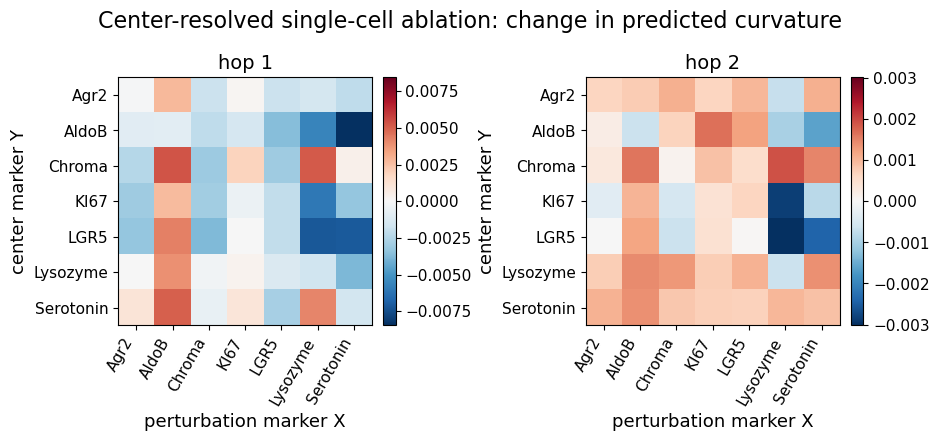

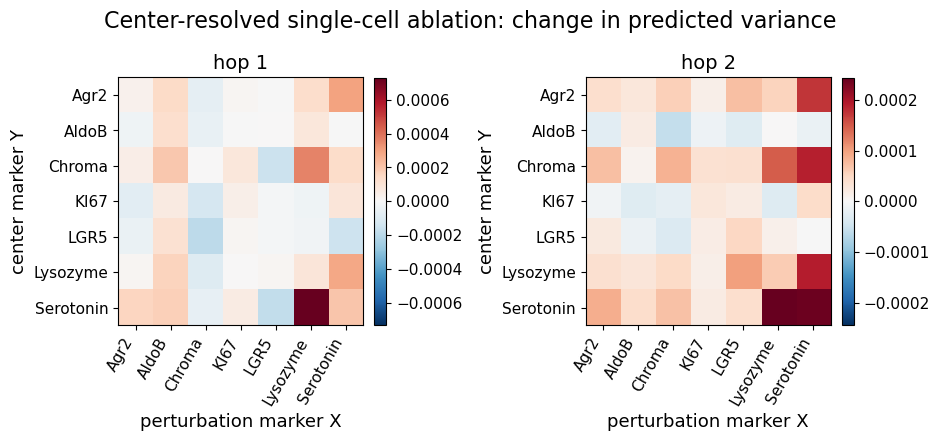

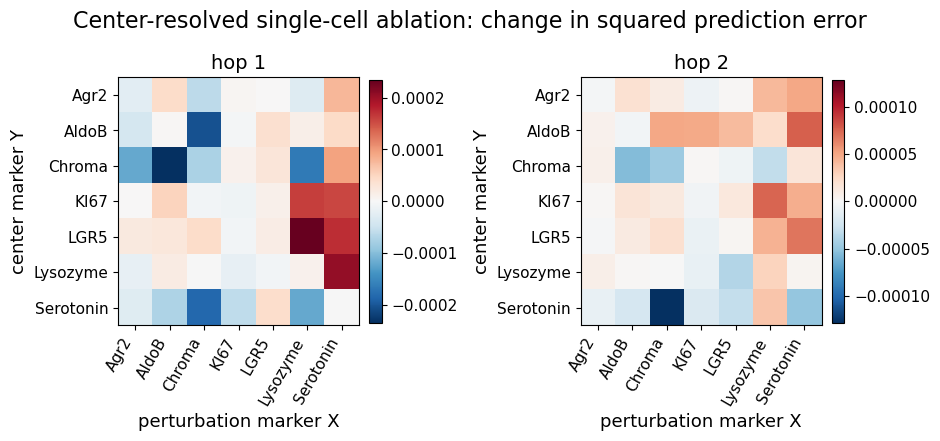

In [97]:
from src.plotting.influence_maps import plot_influence_center_resolved


def center_resolved_arrays(summary_df, metric):
    hops = list(range(1, NUM_LAYERS + 1))
    n_markers = len(marker_names)
    means = np.full((len(hops), n_markers, n_markers), np.nan, dtype=float)
    counts = np.zeros((len(hops), n_markers, n_markers), dtype=int)
    marker_to_idx = {marker: i for i, marker in enumerate(marker_names)}
    subset = summary_df[summary_df["metric"] == metric]
    for row in subset.itertuples(index=False):
        if row.center_marker not in marker_to_idx:
            continue
        hi = hops.index(int(row.hop))
        ci = marker_to_idx[row.center_marker]
        si = int(row.source_marker)
        means[hi, ci, si] = row.mean_effect
        counts[hi, ci, si] = row.cases
    return means, counts, hops


for metric, spec in METRICS.items():
    values, counts, hops = center_resolved_arrays(center_summary_df, metric)
    fig, axes = plot_influence_center_resolved(
        values,
        hops,
        marker_names,
        f"Center-resolved single-cell ablation: {spec['label']}",
        center_zero=True,
        sort_center=False,
        cmap="RdBu_r",
        counts=counts,
        min_count=HEATMAP_DISPLAY_MIN_CASES,
        bad_color="white",
    )
    save_figure(fig, f"center_resolved_{spec['short']}_heatmaps")
    plt.show()


## 8. Population Effects

`conditional_effect` estimates the average change among centers where marker `X` is present at distance `d`. `prevalence_weighted_effect` multiplies this conditional effect by the population prevalence of such centers. Marker-specific top-ups contribute only to the conditional estimate; prevalence is always estimated from the untouched representative average-organoid sample.


In [98]:
population_prevalence_df = pd.concat(
    population_prevalence_tables,
    ignore_index=True,
)
prevalence_summary_df = (
    population_prevalence_df
    .assign(weighted_prevalence=lambda df: df["fold_share"] * df["prevalence"])
    .groupby(["marker", "source_marker", "hop"], as_index=False)
    .agg(prevalence=("weighted_prevalence", "sum"))
)


def summarize_population_effects(case_df, prevalence_df):
    rows = []
    group_columns = ["marker", "source_marker", "hop"]
    prevalence_lookup = {
        (row.marker, int(row.source_marker), int(row.hop)): float(row.prevalence)
        for row in prevalence_df.itertuples(index=False)
    }
    for keys, group in case_df.groupby(group_columns, dropna=False, sort=True):
        marker, source_marker, hop = keys
        weights = group["analysis_weight"].to_numpy(float)
        prevalence = prevalence_lookup[(marker, int(source_marker), int(hop))]
        for metric in METRICS:
            values = group[metric].to_numpy(float)
            conditional = weighted_mean(values, weights)
            conditional_std = weighted_std(values, weights)
            n_effective = effective_sample_size(weights)
            conditional_sem = (
                conditional_std / np.sqrt(n_effective)
                if np.isfinite(conditional_std) and n_effective > 0
                else np.nan
            )
            rows.append({
                "weighting": POPULATION_WEIGHTING,
                "marker": marker,
                "source_marker": int(source_marker),
                "hop": int(hop),
                "metric": metric,
                "prevalence": prevalence,
                "conditional_effect": conditional,
                "conditional_std": conditional_std,
                "conditional_sem": conditional_sem,
                "prevalence_weighted_effect": prevalence * conditional,
                "prevalence_weighted_std": prevalence * conditional_std,
                "prevalence_weighted_sem": prevalence * conditional_sem,
                "cases": len(group),
                "effective_cases": n_effective,
            })
    return pd.DataFrame(rows)


population_summary_df = summarize_population_effects(
    population_filtered_df,
    prevalence_summary_df,
)
population_summary_df.to_csv(TABLES_DIR / "population_effect_summary.csv", index=False)
prevalence_summary_df.to_csv(TABLES_DIR / "population_marker_prevalence.csv", index=False)
display(population_summary_df.head(15))


,weighting,marker,source_marker,hop,metric,prevalence,conditional_effect,conditional_std,conditional_sem,prevalence_weighted_effect,prevalence_weighted_std,prevalence_weighted_sem,cases,effective_cases
0,organoid,Agr2,0,0,delta_mu,0.053049,-0.001422,0.008058,0.000425,-0.000075,0.000427,2.257154e-05,507,358.620428
1,organoid,Agr2,0,0,delta_variance,0.053049,-0.000034,0.000332,0.000018,-0.000002,0.000018,9.294621e-07,507,358.620428
2,organoid,Agr2,0,0,delta_mse,0.053049,0.000020,0.001023,0.000054,0.000001,0.000054,2.865054e-06,507,358.620428
3,organoid,Agr2,0,1,delta_mu,0.213827,-0.002370,0.005148,0.000126,-0.000507,0.001101,2.683678e-05,2053,1682.683586
4,organoid,Agr2,0,1,delta_variance,0.213827,-0.000066,0.000256,0.000006,-0.000014,0.000055,1.336723e-06,2053,1682.683586
5,organoid,Agr2,0,1,delta_mse,0.213827,0.000020,0.000673,0.000016,0.000004,0.000144,3.505901e-06,2053,1682.683586
6,organoid,Agr2,0,2,delta_mu,0.362060,-0.000041,0.002075,0.000038,-0.000015,0.000751,1.359339e-05,3448,3055.474187
7,organoid,Agr2,0,2,delta_variance,0.362060,-0.000019,0.000158,0.000003,-0.000007,0.000057,1.033688e-06,3448,3055.474187
8,organoid,Agr2,0,2,delta_mse,0.362060,0.000007,0.000219,0.000004,0.000003,0.000079,1.436649e-06,3448,3055.474187
9,organoid,AldoB,1,0,delta_mu,0.407703,-0.001122,0.007678,0.000126,-0.000458,0.003130,5.143343e-05,4046,3704.099642


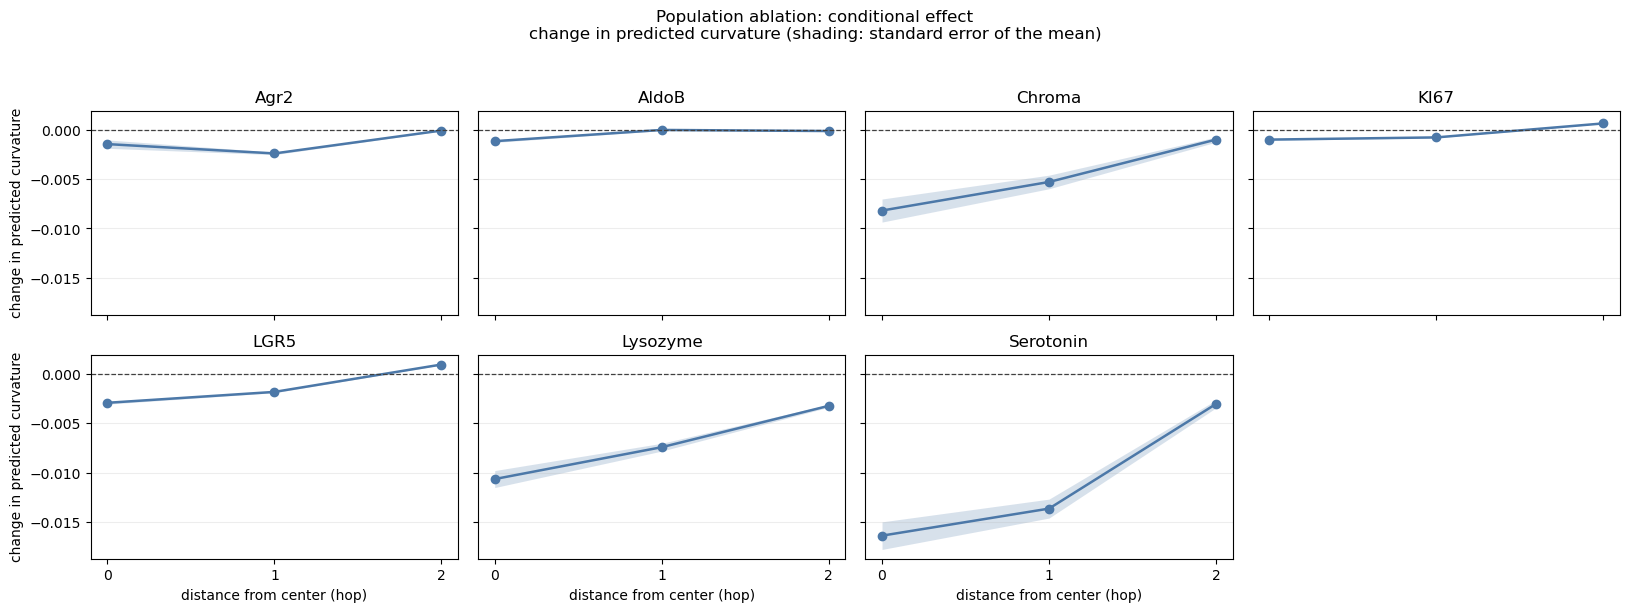

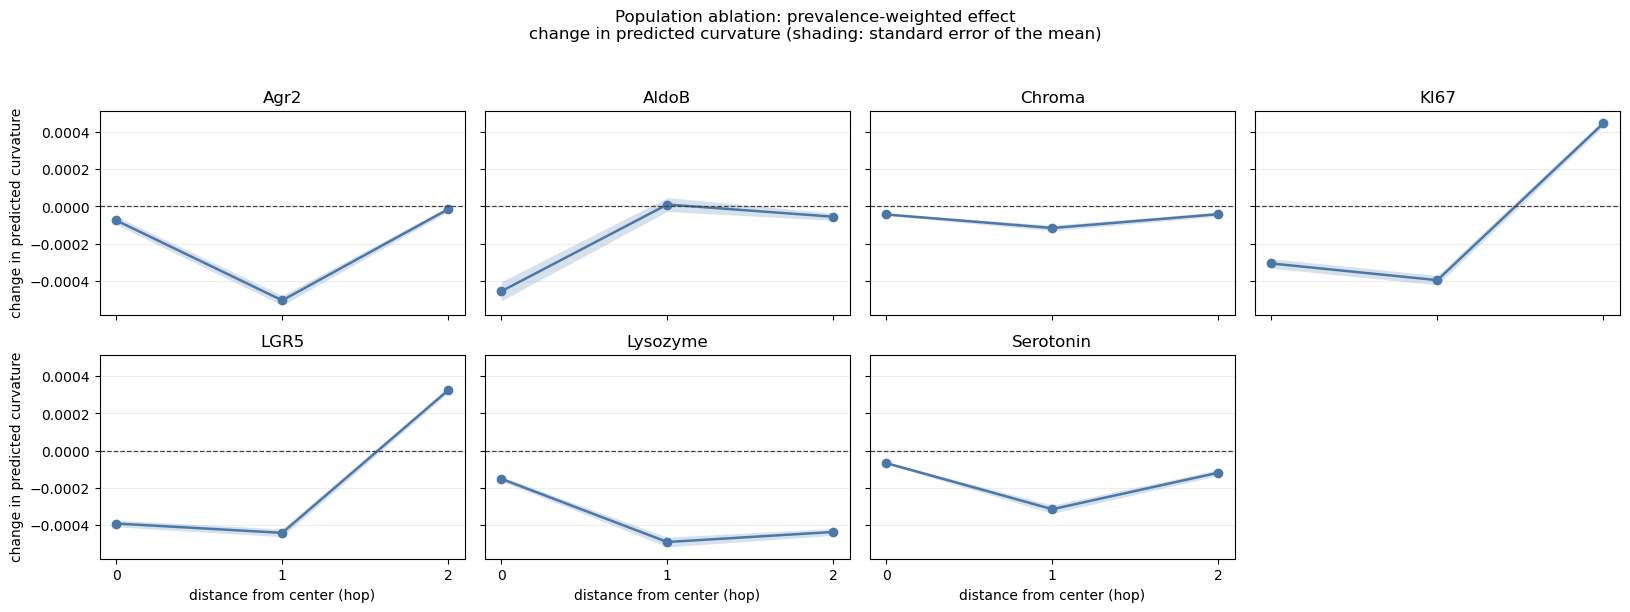

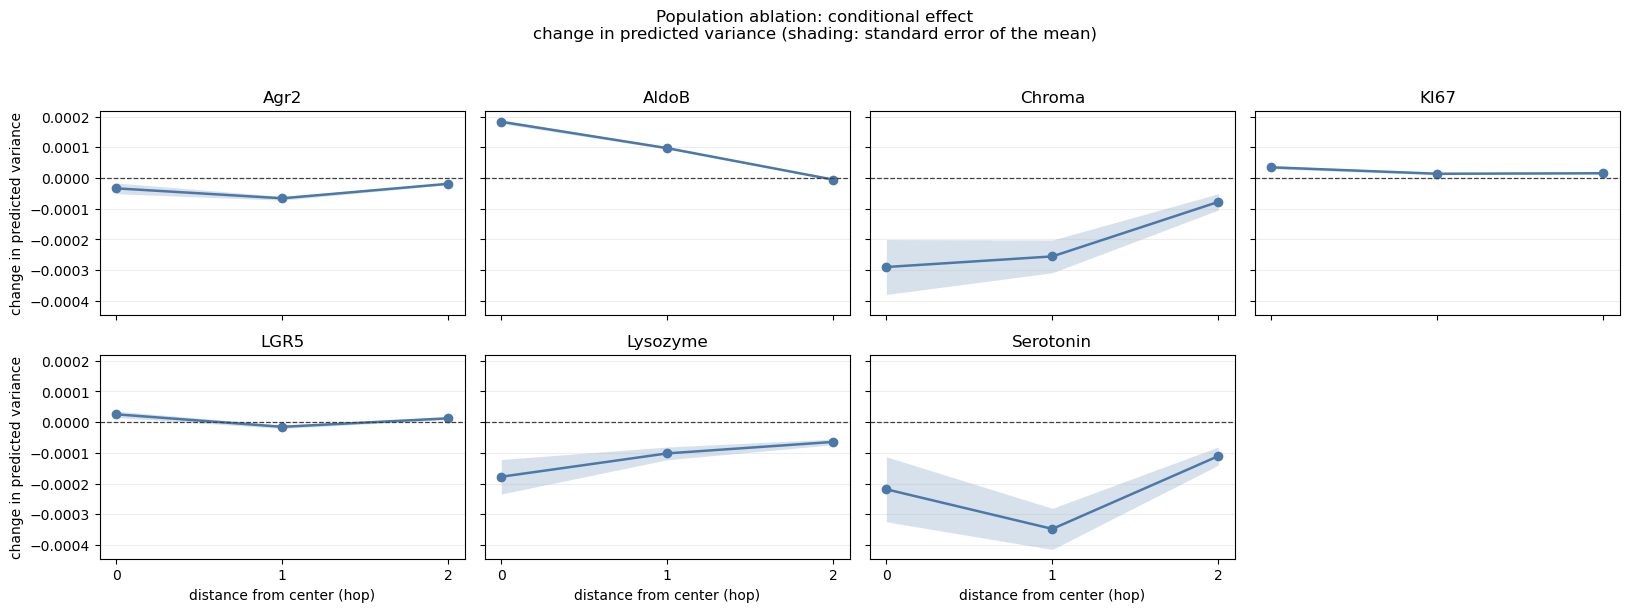

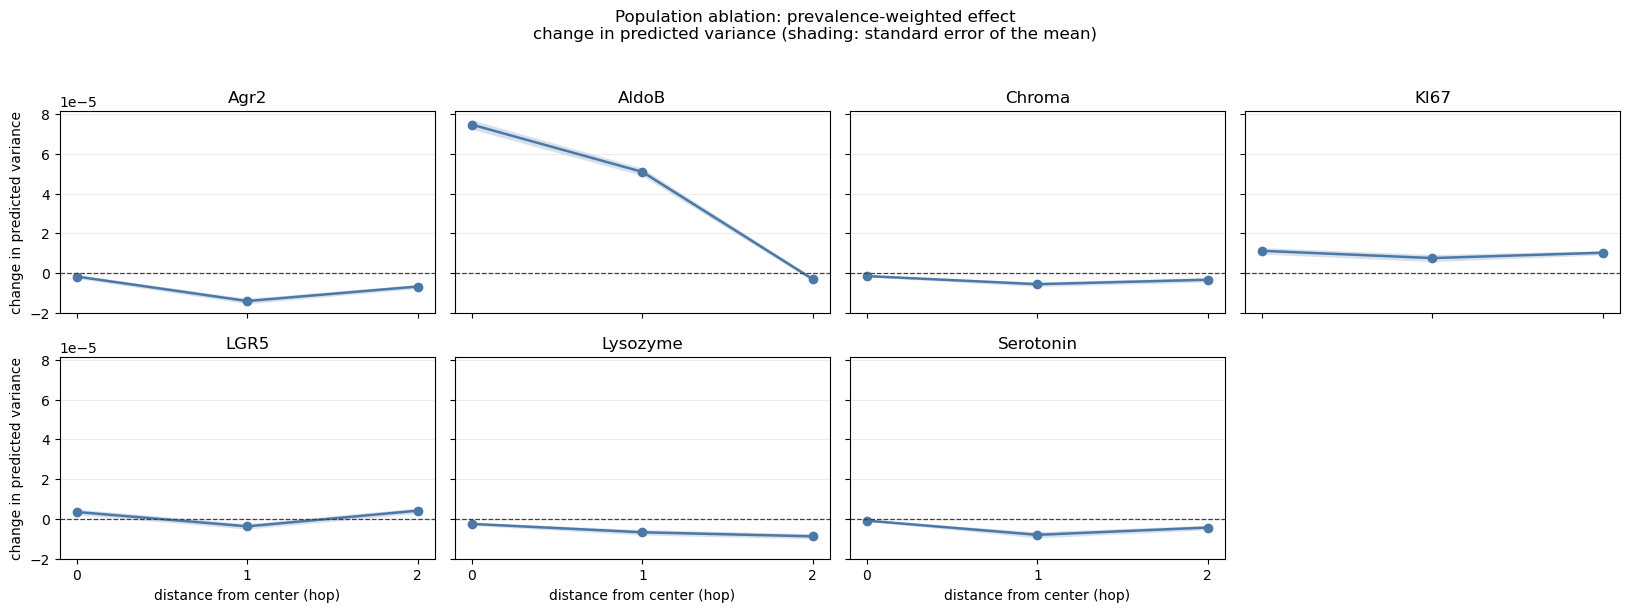

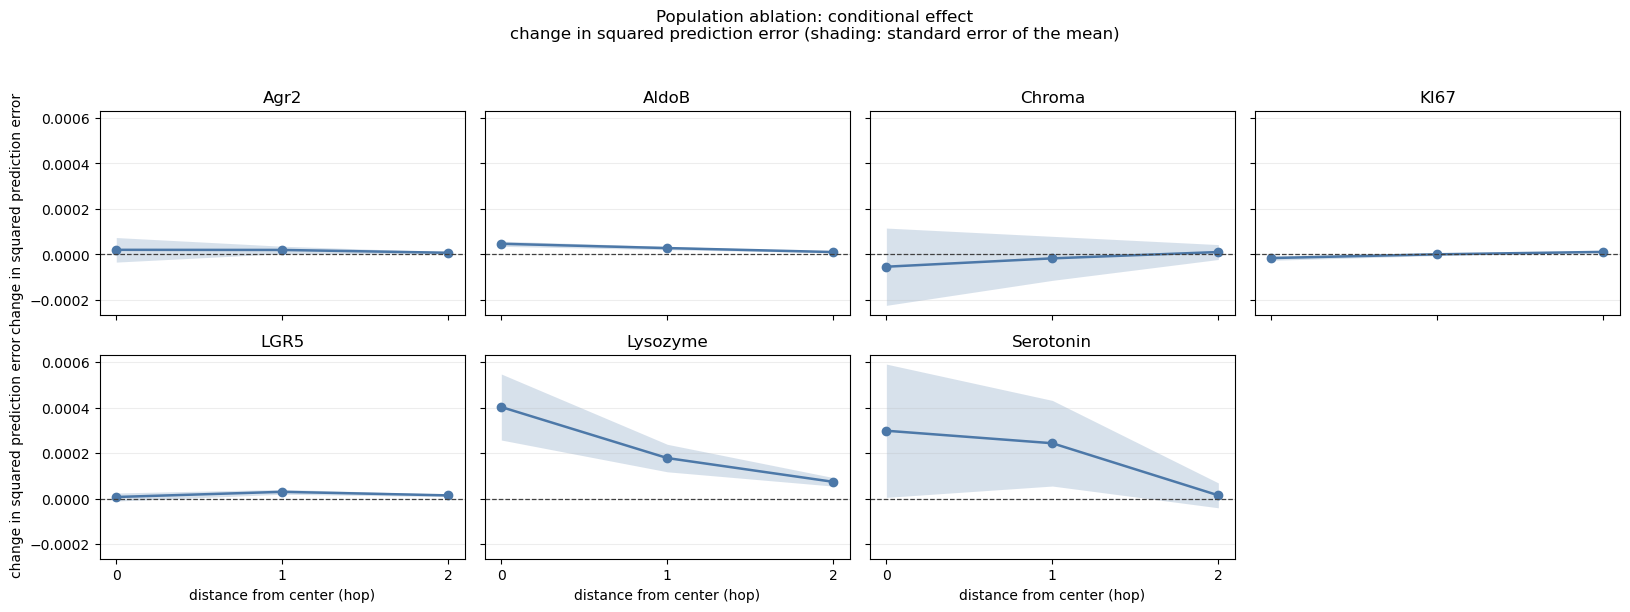

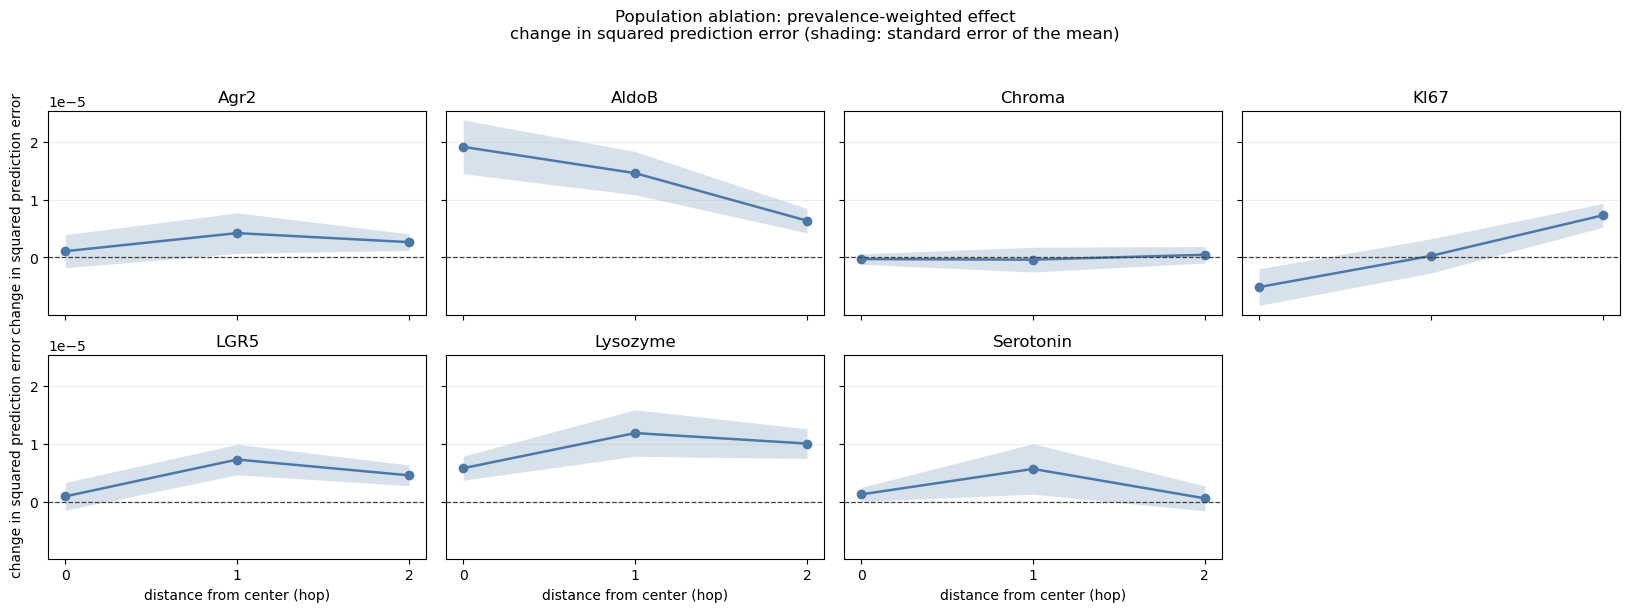

In [99]:
def plot_population_metric_by_marker(
    summary_df,
    metric,
    value_column,
    sem_column,
    estimand_label,
    filename,
):
    spec = METRICS[metric]
    metric_df = summary_df[summary_df["metric"] == metric]
    n_markers = len(marker_names)
    n_cols = 4
    n_rows = 2
    if n_markers > n_rows * n_cols:
        raise ValueError("The 2x4 population layout supports at most eight markers.")
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4.1 * n_cols, 3.1 * n_rows),
        sharex=True,
        sharey=True,
        squeeze=False,
    )
    axes = axes.ravel()
    color = "#4C78A8"

    for ax, marker in zip(axes, marker_names):
        marker_df = metric_df[metric_df["marker"] == marker].sort_values("hop")
        hops = marker_df["hop"].to_numpy(float)
        means = marker_df[value_column].to_numpy(float)
        sems = marker_df[sem_column].to_numpy(float)
        ax.plot(
            hops,
            means,
            marker="o",
            linewidth=1.8,
            color=color,
        )
        valid_band = np.isfinite(hops) & np.isfinite(means) & np.isfinite(sems)
        if np.any(valid_band):
            ax.fill_between(
                hops[valid_band],
                means[valid_band] - sems[valid_band],
                means[valid_band] + sems[valid_band],
                color=color,
                alpha=0.22,
                linewidth=0,
            )
        ax.axhline(0, color="0.25", linestyle="--", linewidth=0.9)
        ax.set_title(marker)
        ax.set_xticks(range(0, NUM_LAYERS + 1))
        ax.grid(axis="y", alpha=0.22)

    for ax in axes[n_markers:]:
        ax.set_visible(False)
    for ax in axes[-n_cols:]:
        if ax.get_visible():
            ax.set_xlabel("distance from center (hop)")
    for row in range(n_rows):
        axes[row * n_cols].set_ylabel(spec["label"])

    fig.suptitle(
        f"Population ablation: {estimand_label}\n"
        f"{spec['label']} (shading: standard error of the mean)"
    )
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    save_figure(fig, filename)
    plt.show()
    return fig, axes


for metric, spec in METRICS.items():
    plot_population_metric_by_marker(
        population_summary_df,
        metric,
        "conditional_effect",
        "conditional_sem",
        "conditional effect",
        f"population_conditional_{spec['short']}",
    )
    plot_population_metric_by_marker(
        population_summary_df,
        metric,
        "prevalence_weighted_effect",
        "prevalence_weighted_sem",
        "prevalence-weighted effect",
        f"population_prevalence_weighted_{spec['short']}",
    )


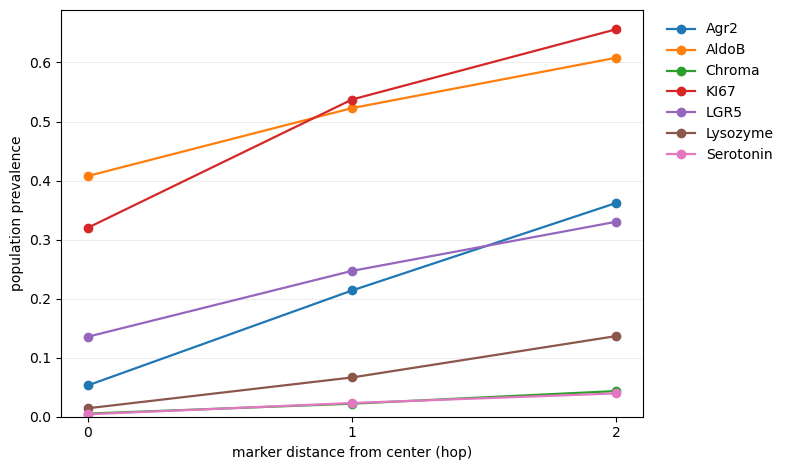

In [100]:
fig, ax = plt.subplots(figsize=(8.0, 4.8))
for marker in marker_names:
    marker_df = prevalence_summary_df[
        prevalence_summary_df["marker"] == marker
    ].sort_values("hop")
    ax.plot(
        marker_df["hop"],
        marker_df["prevalence"],
        marker="o",
        linewidth=1.6,
        label=marker,
    )
ax.set_xlabel("marker distance from center (hop)")
ax.set_ylabel("population prevalence")
ax.set_xticks(range(0, NUM_LAYERS + 1))
ax.set_ylim(bottom=0)
ax.grid(axis="y", alpha=0.22)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
fig.tight_layout()
save_figure(fig, "population_marker_prevalence")
plt.show()


## 9. Sampling Diagnostics And Save Results

In [101]:
center_sampling_summary_df = pd.concat(
    center_sampling_summary_tables,
    ignore_index=True,
)
center_pair_sampling_df = pd.concat(
    center_pair_sampling_tables,
    ignore_index=True,
)
population_sampling_summary_df = pd.concat(
    population_sampling_summary_tables,
    ignore_index=True,
)
sampling_diagnostics_df = pd.concat(
    sampling_diagnostic_tables,
    ignore_index=True,
)

center_sampling_summary_df.to_csv(
    TABLES_DIR / "center_sampling_summary.csv",
    index=False,
)
center_pair_sampling_df.to_csv(
    TABLES_DIR / "center_pair_sampling_summary.csv",
    index=False,
)
population_sampling_summary_df.to_csv(
    TABLES_DIR / "population_sampling_summary.csv",
    index=False,
)
sampling_diagnostics_df.to_csv(
    TABLES_DIR / "population_marker_hop_sampling_summary.csv",
    index=False,
)
prediction_summary_df.to_csv(TABLES_DIR / "prediction_summary.csv", index=False)
split_summary_df.to_csv(TABLES_DIR / "split_summary.csv", index=False)

display(center_sampling_summary_df)
display(population_sampling_summary_df)
display(sampling_diagnostics_df.head(15))


,fold,marker,n_available_subgraphs,n_selected_subgraphs,global_center_count,target_center_count,selected_center_count,target_met
0,0,Agr2,65245,2000,3656,50,197,True
1,0,AldoB,65245,2000,23658,50,725,True
2,0,Chroma,65245,2000,264,50,74,True
3,0,KI67,65245,2000,19788,50,650,True
4,0,LGR5,65245,2000,9368,50,284,True
5,0,Lysozyme,65245,2000,999,50,95,True
6,0,Serotonin,65245,2000,225,50,78,True
7,1,Agr2,68469,2000,3145,50,157,True
8,1,AldoB,68469,2000,25977,50,737,True
9,1,Chroma,68469,2000,364,50,86,True


,fold,weighting,n_available_subgraphs,n_population_subgraphs,n_represented_organoids,min_marker_count_per_hop,includes_hop_zero
0,0,organoid,65245,2000,142,75,True
1,1,organoid,68469,2000,141,75,True
2,2,organoid,72716,2000,141,75,True
3,3,organoid,68273,2000,141,75,True
4,4,organoid,63680,2000,141,75,True


,fold,marker,hop,available,sampled,topped_up,population_size
0,0,Agr2,0,3656,135,0,2000
1,0,Agr2,1,14059,471,0,2000
2,0,Agr2,2,23458,766,0,2000
3,0,AldoB,0,23658,732,0,2000
4,0,AldoB,1,31339,1000,0,2000
5,0,AldoB,2,37258,1190,0,2000
6,0,Chroma,0,264,75,62,2000
7,0,Chroma,1,1194,75,31,2000
8,0,Chroma,2,2399,96,0,2000
9,0,KI67,0,19788,611,0,2000


In [102]:
config = {
    "experiment_group": EXPERIMENT_GROUP,
    "analysis_mode": ANALYSIS_MODE,
    "dataset_name": DATASET_NAME,
    "target_indices": TARGET_INDICES,
    "target_index_for_analysis": TARGET_INDEX_FOR_ANALYSIS,
    "n_graphs_after_filtering": len(graphs),
    "marker_names": list(marker_names),
    "split": {
        "val_frac": VAL_FRAC,
        "n_folds": N_FOLDS,
        "seed": SPLIT_SEED,
    },
    "filtering": {
        "timepoint_filter_mode": TIMEPOINT_FILTER_MODE,
        "day3p5_timepoint": DAY3P5_TIMEPOINT,
        "filter_blacklisted_organoids": FILTER_BLACKLISTED_ORGANOIDS,
        "blacklist_n_keys": len(blacklist),
        "fill_missing_complexity": FILL_MISSING_COMPLEXITY,
        "missing_complexity_group": MISSING_COMPLEXITY_GROUP,
        "sphericity_max": SPHERICITY_MAX,
        "spherical_marker_diversity_min": SPHERICAL_MARKER_DIVERSITY_MIN,
        "complexity_min": COMPLEXITY_MIN,
        "interpolate_target_outliers": INTERPOLATE_TARGET_OUTLIERS,
        "outlier_clip_quantiles": OUTLIER_CLIP_QUANTILES,
    },
    "model": {
        "num_layers": NUM_LAYERS,
        "hidden_dim": HIDDEN_DIM,
        "dropout": DROPOUT,
        "norm": NORM,
        "residual": RESIDUAL,
        "use_global_features": USE_GLOBAL_FEATURES,
        "subtract_constant_global_baseline": SUBTRACT_CONSTANT_GLOBAL_BASELINE,
    },
    "training": {
        "lr": LR,
        "batch_size": BATCH_SIZE,
        "max_epochs": MAX_EPOCHS,
        "patience": PATIENCE,
        "num_workers": NUM_WORKERS,
        "edge_loss_weight": EDGE_LOSS_WEIGHT,
        "edge_loss_params": EDGE_LOSS_PARAMS,
    },
    "perturbation": {
        "mode": PERTURBATION_MODE,
        "center_sample_size": CENTER_SAMPLE_SIZE,
        "center_min_marker_count": CENTER_MIN_MARKER_COUNT,
        "center_min_pair_count": CENTER_MIN_PAIR_COUNT,
        "heatmap_display_min_cases": HEATMAP_DISPLAY_MIN_CASES,
        "population_sample_size": POPULATION_SAMPLE_SIZE,
        "population_weighting": POPULATION_WEIGHTING,
        "min_marker_count_per_hop": MIN_MARKER_COUNT_PER_HOP,
        "population_includes_hop_zero": True,
        "center_resolved_includes_hop_zero": False,
        "outlier_filter_method": OUTLIER_FILTER_METHOD,
        "outlier_mad_z": OUTLIER_MAD_Z,
        "outlier_min_group_size": OUTLIER_MIN_GROUP_SIZE,
        "outlier_tail": OUTLIER_TAIL,
        "outlier_mask_source_metric": "delta_mu",
        "outlier_mask_applied_to": list(METRICS),
    },
}

for settings_name in ("settings.json", "config.json"):
    with open(SAVE_DIR / settings_name, "w") as f:
        json.dump(jsonable(config), f, indent=2)
with open(SAVE_DIR / "training_logs.pkl", "wb") as f:
    pickle.dump(training_logs, f)
with open(SAVE_DIR / "meta.json", "w") as f:
    json.dump({
        "timestamp": datetime.now().isoformat(),
        "notes": (
            "Single-marker center-resolved and average-organoid population "
            "ablation analysis. Curvature-derived MAD flags are shared across metrics."
        ),
    }, f, indent=2)

print("Saved analysis to", SAVE_DIR)


Saved analysis to /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/ablation_analysis/folded_depth2_20260611_100949
